EXPERIMENT 9
Deep Q-Network (DQN) using TensorFlow and Keras
Episode: 10 | Reward: 11.0 | Loss: 0.1419 | Epsilon: 0.737
Episode: 20 | Reward: 16.0 | Loss: 0.1173 | Epsilon: 0.544
Episode: 30 | Reward: 12.0 | Loss: 0.3816 | Epsilon: 0.401
Episode: 40 | Reward: 10.0 | Loss: 0.5918 | Epsilon: 0.296
Episode: 50 | Reward: 9.0 | Loss: 0.2527 | Epsilon: 0.218
Episode: 60 | Reward: 10.0 | Loss: 0.8755 | Epsilon: 0.161
Episode: 70 | Reward: 9.0 | Loss: 0.7867 | Epsilon: 0.119
Episode: 80 | Reward: 9.0 | Loss: 1.4444 | Epsilon: 0.087
Episode: 90 | Reward: 23.0 | Loss: 0.7139 | Epsilon: 0.064
Episode: 100 | Reward: 37.0 | Loss: 0.5216 | Epsilon: 0.05


FULL DATASET


,Episode,Reward,Loss,Epsilon,Steps
0,1,24.0,0.000000,0.970000,24
1,2,13.0,0.550686,0.940900,13
2,3,17.0,0.505650,0.912673,17
3,4,20.0,0.485680,0.885293,20
4,5,16.0,0.456879,0.858734,16
...,...,...,...,...,...
95,96,12.0,0.190942,0.053714,12
96,97,11.0,0.388897,0.052102,11
97,98,13.0,0.941725,0.050539,13
98,99,18.0,0.539064,0.050000,18


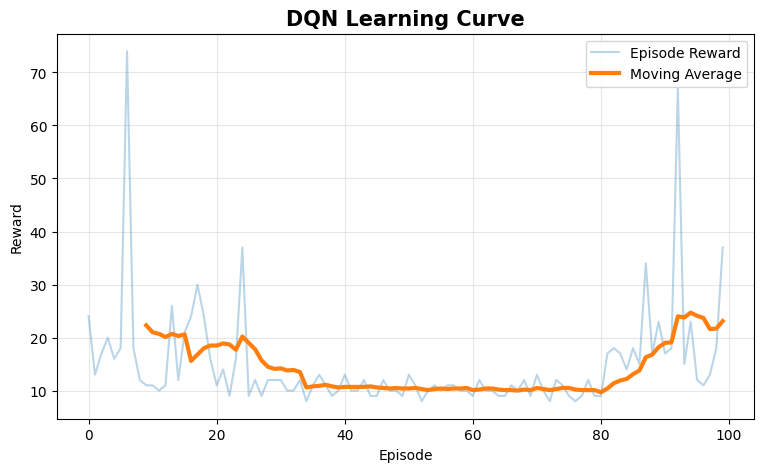

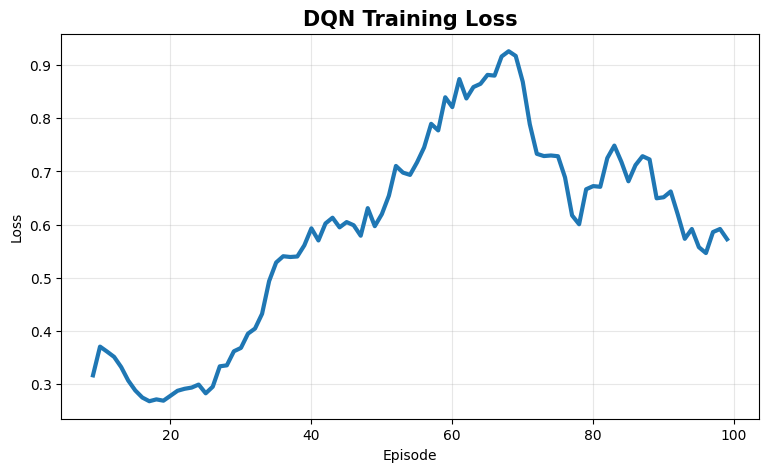

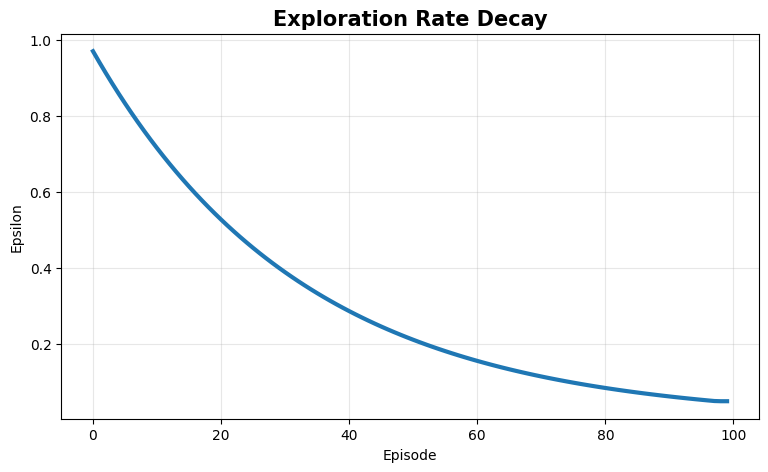

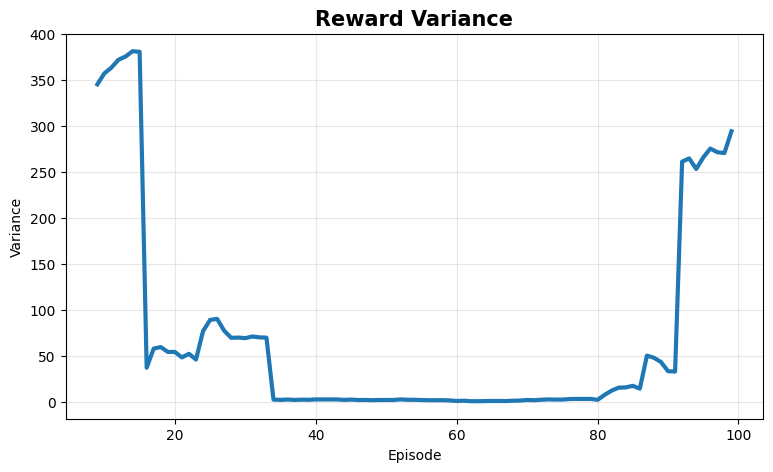

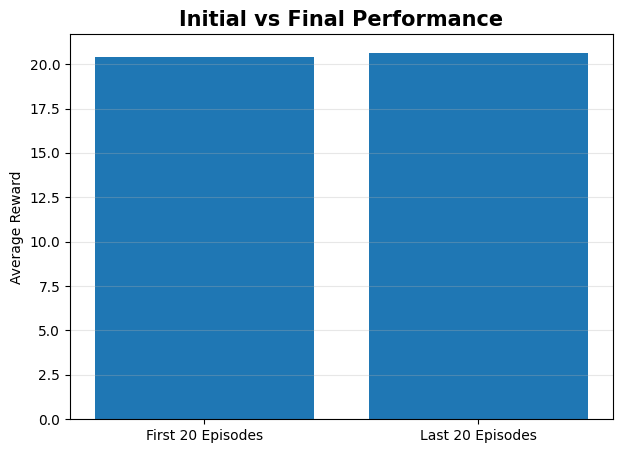



SUMMARY TABLE


,Parameter,Result
0,Algorithm,DQN
1,Environment,CartPole-v1
2,Episodes,100
3,Final Average Reward,20.65
4,Maximum Reward,74.0
5,Reward Variance,166.13
6,Average Steps,20.65
7,Training Time,159.32




RESULT
Final Average Reward: 20.65
Maximum Reward: 74.0
Reward Variance: 166.13
Average Steps: 20.65
Training Time: 159.32 seconds


CONCLUSION
DQN was successfully implemented using TensorFlow and Keras.
The agent learned using experience replay and a target network.
The epsilon-greedy strategy was used for exploration and exploitation.
The learning curve, loss, epsilon decay and reward variance were analyzed.
The final training performance was compared with the initial performance.

Files Created:
DQN_Full_Dataset.csv
DQN_Summary.csv

Experiment 9 Completed Successfully.


In [1]:
!pip -q install gymnasium tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
import time

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("="*65)
print("EXPERIMENT 9")
print("Deep Q-Network (DQN) using TensorFlow and Keras")
print("="*65)

env=gym.make("CartPole-v1")

state_size=4
action_size=2
episodes=100
gamma=0.95
learning_rate=0.001
epsilon=1.0
epsilon_min=0.05
epsilon_decay=0.97
batch_size=32
memory=deque(maxlen=3000)
train_frequency=4
target_update=10

def create_model():
    model=Sequential([
        Input(shape=(4,)),
        Dense(32,activation="relu"),
        Dense(32,activation="relu"),
        Dense(2,activation="linear")
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model

model=create_model()
target_model=create_model()
target_model.set_weights(model.get_weights())

def get_action(state):
    if np.random.random()<epsilon:
        return np.random.randint(2)
    q=model.predict(
        np.array([state],dtype=np.float32),
        verbose=0
    )
    return int(np.argmax(q[0]))

def train_model():
    if len(memory)<batch_size:
        return 0

    batch=random.sample(memory,batch_size)

    states=np.array(
        [x[0] for x in batch],
        dtype=np.float32
    )
    actions=np.array(
        [x[1] for x in batch]
    )
    rewards=np.array(
        [x[2] for x in batch],
        dtype=np.float32
    )
    next_states=np.array(
        [x[3] for x in batch],
        dtype=np.float32
    )
    dones=np.array(
        [x[4] for x in batch]
    )

    current_q=model.predict(
        states,
        verbose=0
    )
    next_q=target_model.predict(
        next_states,
        verbose=0
    )

    targets=current_q.copy()

    for i in range(batch_size):
        if dones[i]:
            targets[i,actions[i]]=rewards[i]
        else:
            targets[i,actions[i]]=(
                rewards[i]+
                gamma*np.max(next_q[i])
            )

    result=model.fit(
        states,
        targets,
        epochs=1,
        verbose=0
    )

    return float(result.history["loss"][0])

reward_list=[]
loss_list=[]
epsilon_list=[]
step_list=[]

start=time.time()

for episode in range(episodes):

    state,_=env.reset()
    total_reward=0
    total_loss=0
    loss_count=0
    steps=0
    done=False

    while not done:

        action=get_action(state)

        next_state,reward,terminated,truncated,_=env.step(action)

        done=terminated or truncated

        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

        if steps%train_frequency==0:
            loss=train_model()
            if loss>0:
                total_loss+=loss
                loss_count+=1

        state=next_state
        total_reward+=reward
        steps+=1

    epsilon=max(
        epsilon_min,
        epsilon*epsilon_decay
    )

    if (episode+1)%target_update==0:
        target_model.set_weights(
            model.get_weights()
        )

    average_loss=(
        total_loss/loss_count
        if loss_count>0
        else 0
    )

    reward_list.append(total_reward)
    loss_list.append(average_loss)
    epsilon_list.append(epsilon)
    step_list.append(steps)

    if (episode+1)%10==0:
        print(
            "Episode:",
            episode+1,
            "| Reward:",
            round(total_reward,2),
            "| Loss:",
            round(average_loss,4),
            "| Epsilon:",
            round(epsilon,3)
        )

training_time=time.time()-start

env.close()

dataset=pd.DataFrame({
    "Episode":range(1,episodes+1),
    "Reward":reward_list,
    "Loss":loss_list,
    "Epsilon":epsilon_list,
    "Steps":step_list
})

print("\n")
print("="*65)
print("FULL DATASET")
print("="*65)

display(dataset)

dataset.to_csv(
    "DQN_Full_Dataset.csv",
    index=False
)

reward_smooth=dataset["Reward"].rolling(10).mean()

plt.figure(figsize=(9,5))
plt.plot(
    dataset["Reward"],
    alpha=0.3,
    label="Episode Reward"
)
plt.plot(
    reward_smooth,
    linewidth=3,
    label="Moving Average"
)
plt.title(
    "DQN Learning Curve",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loss_smooth=dataset["Loss"].rolling(10).mean()

plt.figure(figsize=(9,5))
plt.plot(
    loss_smooth,
    linewidth=3
)
plt.title(
    "DQN Training Loss",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(
    dataset["Epsilon"],
    linewidth=3
)
plt.title(
    "Exploration Rate Decay",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(alpha=0.3)
plt.show()

variance=dataset["Reward"].rolling(10).var()

plt.figure(figsize=(9,5))
plt.plot(
    variance,
    linewidth=3
)
plt.title(
    "Reward Variance",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(alpha=0.3)
plt.show()

first_reward=dataset["Reward"].head(20).mean()
last_reward=dataset["Reward"].tail(20).mean()

plt.figure(figsize=(7,5))
plt.bar(
    ["First 20 Episodes","Last 20 Episodes"],
    [first_reward,last_reward]
)
plt.title(
    "Initial vs Final Performance",
    fontsize=15,
    fontweight="bold"
)
plt.ylabel("Average Reward")
plt.grid(axis="y",alpha=0.3)
plt.show()

final_reward=dataset["Reward"].tail(20).mean()
maximum_reward=dataset["Reward"].max()
final_variance=dataset["Reward"].tail(20).var()
average_steps=dataset["Steps"].tail(20).mean()

summary=pd.DataFrame({
    "Parameter":[
        "Algorithm",
        "Environment",
        "Episodes",
        "Final Average Reward",
        "Maximum Reward",
        "Reward Variance",
        "Average Steps",
        "Training Time"
    ],
    "Result":[
        "DQN",
        "CartPole-v1",
        episodes,
        round(final_reward,2),
        round(maximum_reward,2),
        round(final_variance,2),
        round(average_steps,2),
        round(training_time,2)
    ]
})

print("\n")
print("="*65)
print("SUMMARY TABLE")
print("="*65)

display(summary)

summary.to_csv(
    "DQN_Summary.csv",
    index=False
)

print("\n")
print("="*65)
print("RESULT")
print("="*65)

print("Final Average Reward:",round(final_reward,2))
print("Maximum Reward:",round(maximum_reward,2))
print("Reward Variance:",round(final_variance,2))
print("Average Steps:",round(average_steps,2))
print("Training Time:",round(training_time,2),"seconds")

print("\n")
print("="*65)
print("CONCLUSION")
print("="*65)

print("DQN was successfully implemented using TensorFlow and Keras.")
print("The agent learned using experience replay and a target network.")
print("The epsilon-greedy strategy was used for exploration and exploitation.")
print("The learning curve, loss, epsilon decay and reward variance were analyzed.")
print("The final training performance was compared with the initial performance.")

print("\nFiles Created:")
print("DQN_Full_Dataset.csv")
print("DQN_Summary.csv")

print("\nExperiment 9 Completed Successfully.")